# Upsampling the redshift distribution

To increase the sample size of the Quasar dataset while preserving the physical distribution of redshifts, two stochastic simulation techniques are implemented. Both methods rely on the experimental PDF $f_z(z)$ derived from the linear interpolation of our original histogram.

In [1]:
!pip install astroML

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as s
from scipy.interpolate import interp1d
from scipy.optimize import brentq

In [3]:
from urllib.request import urlretrieve

In [4]:
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './drsqso.dat')

('./drsqso.dat', <http.client.HTTPMessage at 0x2b27a7acbd0>)

In [5]:
# There are 80 header lines, skip them. The redfshift is in column 3. 
#Careful that there's another z feature, but that refers to the SDSS z filter, not the redshift
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

# Method 1: Rejection sampling

The rejection sampling method is an intuitive "hit-or-miss" technique. 
The target distribution $f(z)$ is wrapped inside a simpler proposal distribution $g(z)$ (a uniform distribution in this case) scaled by a constant $M$ such that $M \cdot g(z) \geq f(z)$ for all $z$.Then a candidate redshift $z_{cand}$ is generated from a uniform distribution between $z_{min}$ and $z_{max}$. and a random vertical threshold $u$ from a uniform distribution between $0$ and $M$.
* If $u < f(z_{cand})$, the point is accepted;
* otherwise, the point is rejected.

In [6]:
def get_experimental_pdf(counts, bin_centers):
    """
    Returns a function representing the linear interpolation 
    of the experimental histogram.
    """
    # kind='linear' creates the straight lines between points
    # fill_value=0 ensures that outside the data range, the PDF is zero
    # bounds_error=False prevents the code from crashing if you ask for a z outside the range
    pdf_func = interp1d(bin_centers, counts, 
                        kind='linear', 
                        bounds_error=False, 
                        fill_value=0.0)
    return pdf_func



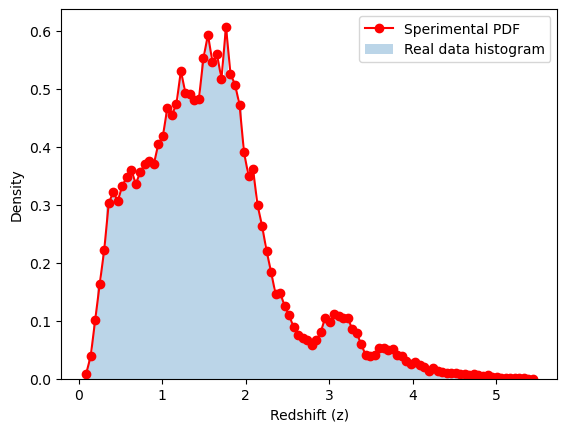

In [7]:
counts, bins = np.histogram(z, bins=100, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2


f_z = get_experimental_pdf(counts, bin_centers)

plt.plot(bin_centers, f_z(bin_centers), '-', marker='o', color='red', label='Sperimental PDF')
plt.hist(z, bins=100, density=True, alpha=0.3, label='Real data histogram')
plt.xlabel('Redshift (z)')
plt.ylabel('Density')
plt.legend()
plt.show()

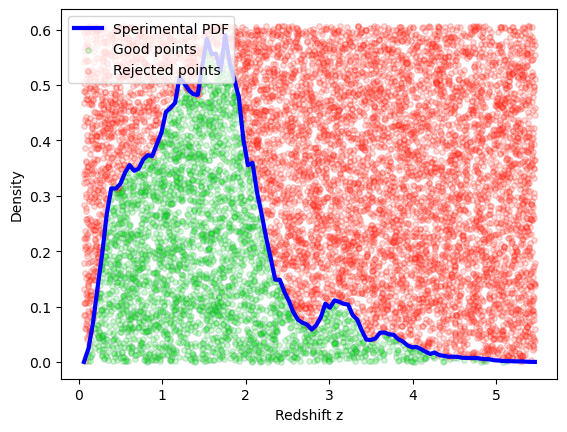

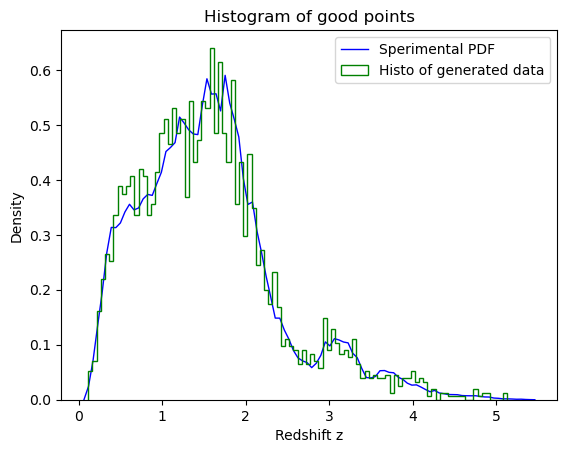

In [8]:
N=10000

z_uni = np.linspace(np.min(z),np.max(z),100)

plt.plot(z_uni,f_z(z_uni),  '-',  color='blue', label='Sperimental PDF', linewidth='3.')


ymax = np.max(f_z(bin_centers))
x = np.random.uniform(np.min(z),np.max(z),N)
y = np.random.uniform(0,ymax,N)
plt.scatter(x[y<f_z(x)],y[y<f_z(x)],c='lime', alpha=0.2, s=15., edgecolors='seagreen', label='Good points')
plt.scatter(x[y>f_z(x)],y[y>f_z(x)],c='tomato', alpha=0.2, s=15., edgecolors='red', label='Rejected points')
plt.xlabel('Redshift z')
plt.ylabel('Density')
plt.legend()
plt.show()
goodpoints = x[y<f_z(x)]

plt.plot(z_uni,f_z(z_uni),  '-',  color='blue', label='Sperimental PDF', linewidth='1.')
plt.hist(goodpoints,bins=100,density=True,histtype='step',color='green', label='Histo of generated data')
plt.xlabel('Redshift z')
plt.ylabel('Density')
plt.title('Histogram of good points')
plt.legend()
plt.show()

# Method 2: Inverse transform sampling

Inverse transform sampling is a highly efficient "direct" method. It bypasses the need to discard points by utilizing the fundamental relationship between a distribution and its Cumulative Distribution Function (CDF), which is computed as $F(z) = \int_{z_{min}}^{z} f(t)dt$.
Then the quantile function $Q(u) = F^{-1}(u)$ is computed (analitically or numerically), which maps a probability $u \in [0, 1]$ back to a redshift $z$. Finally, from a generated uniform random number $u \sim U(0,1)$, $z = Q(u)$ is calculated.

In [9]:
z_grid = np.linspace(z.min(), z.max(), 1000)
pdf_values = f_z(z_grid)

# Compute CDF (integral of PDF)
# use cumsum and multiply for the step (dx) 
dz = z_grid[1] - z_grid[0]  
cdf_values = np.cumsum(pdf_values) * dz
cdf_values /= cdf_values[-1]  # Normalization to end to 1.0

Text(0, 0.5, 'cdf(z)')

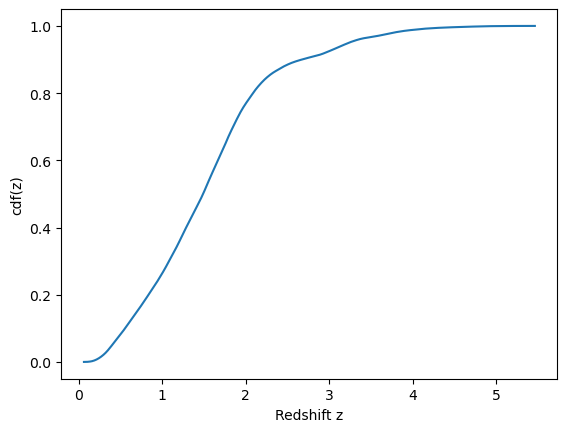

In [10]:
plt.plot(z_grid, cdf_values, '-')
plt.xlabel('Redshift z')
plt.ylabel('cdf(z)')

In [11]:
from scipy.interpolate import interp1d

cdf_func= interp1d(z_grid, cdf_values, kind='linear', bounds_error=False, fill_value="extrapolate")
# Invert: x is the probability (0-1), y is the redshift (z)
quantile_func = interp1d(cdf_values, z_grid, kind='linear', bounds_error=False, fill_value="extrapolate")


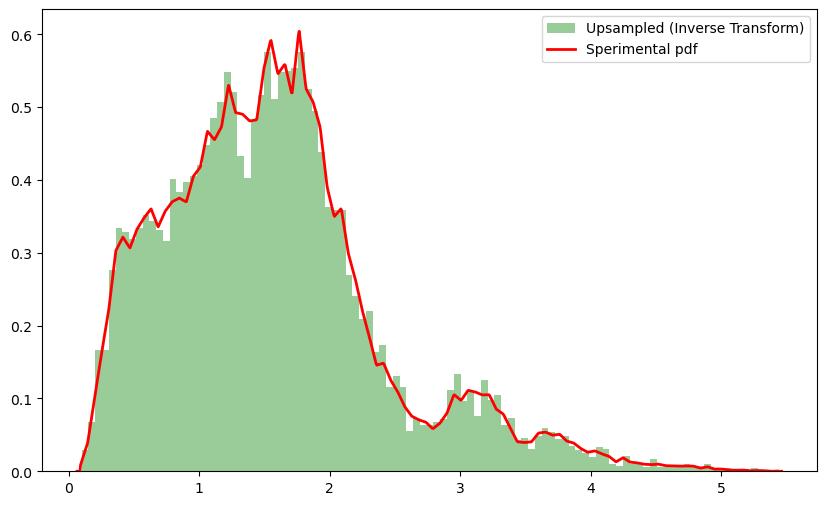

In [12]:
#1st way by using the interpolated inverse

N = 10000
u = np.random.uniform(0, 1, N) #generate from unif. distr.

# Take the inverse
z_new = quantile_func(u)
plt.figure(figsize=(10, 6))
plt.hist(z_new, bins=100, density=True, alpha=0.4, color='green', label='Upsampled (Inverse Transform)')
plt.plot(z_grid, pdf_values, 'r-', lw=2, label='Sperimental pdf')
plt.legend()
plt.show()

In [13]:
#2nd way using a numerically root finder
eps = np.random.uniform(0,1,N)

# Using a vanilla root finder, which solves for cdf(h)=eps i.e. finds the zero of the function cdf(x)-eps

samples = [ brentq(lambda h: cdf_func(h) - e, np.min(z), np.max(z)) for e in eps]



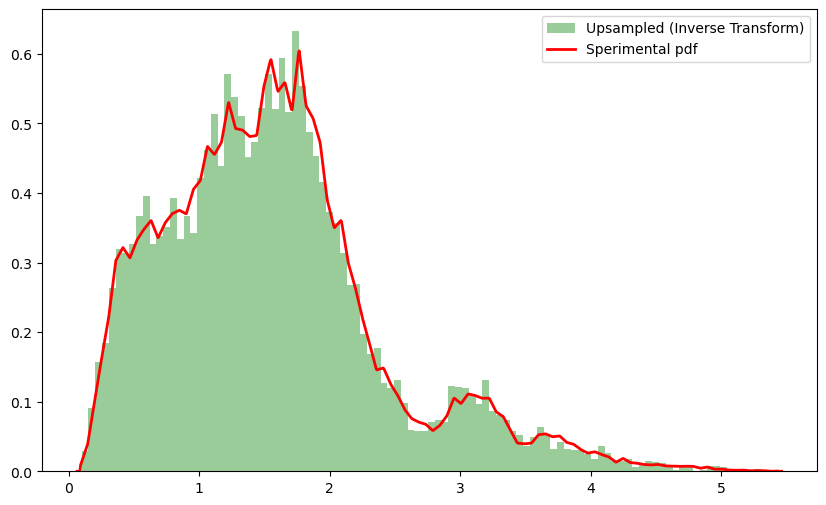

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(samples,bins=100, density=True, alpha=0.4, color='green', label='Upsampled (Inverse Transform)')
plt.plot(z_grid, pdf_values, 'r-', lw=2, label='Sperimental pdf')
plt.legend()
plt.show()

# Method 3: scipy.stats reverse sampling

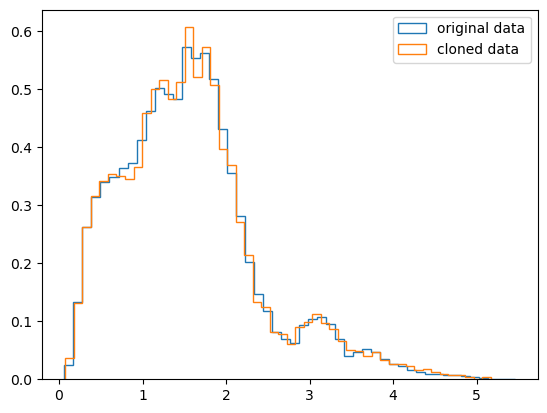

In [16]:
import scipy
plt.hist(z,bins=50,histtype='step',density=True,label='original data');

# make a histogram object
counts, bins = np.histogram(z, bins=50, density=True)

# Make a scipy.stats random variable object from a histogram
disth = scipy.stats.rv_histogram((counts,bins))

plt.hist(disth.rvs(size=N),bins=50,density=True,histtype='step',label='cloned data');

plt.legend()

# Final comparison and cosmological interpretation

After performing both rejection sampling and inverse transform sampling, the generated "cloned" distributions is compared with the original SDSS observed data.

The histograms of the synthetic samples (green) should align with the experimental PDF (the red interpolation line). This confirms that the sampling algorithms correctly captured the localized density variations of the Quasar population.

The Cumulative Distribution Function is the most rigorous visual test. If the CDF of the cloned data overlaps with the empirical CDF of the SDSS data, the upsampling is statistically consistent.

Now the data are compared to an overplotted theoretical distribution based on a simplified cosmological model where Quasars have a constant comoving density (i.e., they are distributed uniformly across the volume of the Universe, considering the Cosmological Principle to hold true). In such a model, the number of observed objects $dN/dz$ should be proportional to the comoving volume element $dV/dz$.


In [19]:
!pip install astropy

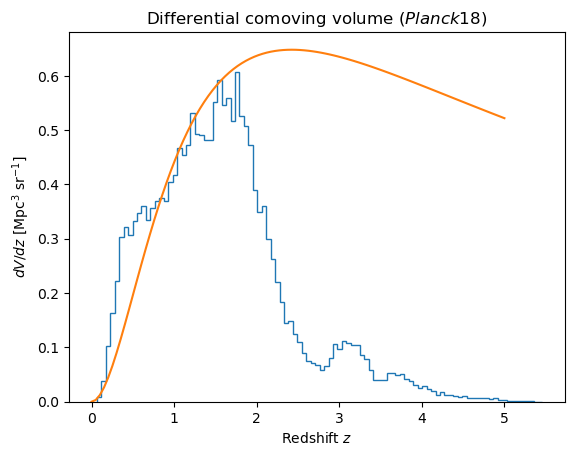

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 

z_vals = np.linspace(0, 5, 100)

comvol = Planck18.differential_comoving_volume(z_vals).value 
plt.hist(z,bins=100,histtype='step',density=True,label='original data')
plt.plot(z_vals, comvol/6.5e10) #arbitrarerly normalization
plt.title("Differential comoving volume ($Planck18$)")
plt.xlabel("Redshift $z$")
plt.ylabel("$dV/dz$ [Mpc$^3$ sr$^{-1}$]")
plt.show()

Why does the theory fail to match the data?

As hinted, the theoretical curve does not agree with the observed SDSS distribution, which peaks around $z \approx 1.5$ and then drops sharply. This discrepancy may be due to two main factors. First of all, Quasars are not steady-state objects. They represent a phase in galaxy evolution. The "Quasar Epoch" occurred at $z \sim 2$, when supermassive black holes were most active. As you move to lower redshifts ($z \to 0$), the fuel supply (gas) decreases and Quasars "turn off." As you move to very high redshifts ($z > 3$), we are looking back to a time when these massive structures were still forming. Then, there may be selection effects as the SDSS is a flux-limited survey. As redshift increases, objects of a given intrinsic luminosity appear fainter (distance modulus). Eventually, they fall below the telescope's detection threshold, causing an artificial drop.